In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
training_dataset_path = "./data/training_data/training_dataset.parquet"

df = pd.read_parquet(training_dataset_path)

Classification Report:
              precision    recall  f1-score   support

         0.0      0.643     0.409     0.500        22
         1.0      0.912     0.964     0.938       140

    accuracy                          0.889       162
   macro avg      0.778     0.687     0.719       162
weighted avg      0.876     0.889     0.878       162



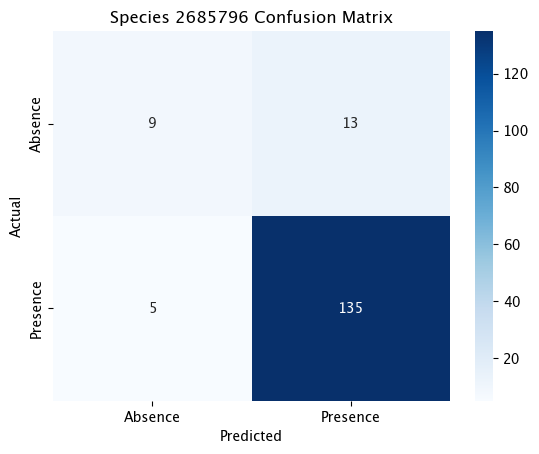

In [3]:


# --- Load your dataset (if not already loaded) ---
# df = pd.read_csv("your_data.csv")

# --- Features and target ---
band_cols = [col for col in df.columns if col.startswith("band_")]
target_col = "2685796"  # your species column (presence/absence)

df_clean = df.dropna(subset=[target_col])
X = df_clean[band_cols]
y = df_clean[target_col]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Model training ---
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# --- Predictions ---
y_pred = clf.predict(X_test)

# --- Metrics ---
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Absence", "Presence"],
            yticklabels=["Absence", "Presence"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Species {target_col} Confusion Matrix")
plt.show()


In [ ]:
# --- Drop missing values from target ---import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier  # Uncomment if working

# --- Define your features and target ---
target_col = "2685796"
X = df[[col for col in df.columns if col.startswith("band_")]].copy()
y = df[target_col].fillna(0).astype(int)  # ensure no NaNs

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Define models ---
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "XGBoost": XGBClassifier(scale_pos_weight=(y == 0).sum() / (y == 1).sum(), use_label_encoder=False, eval_metric='logloss', verbosity=0),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=42),
}

# --- Evaluate each model ---
results = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# --- Display results ---
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)

import caas_jupyter_tools as cjtools
cjtools.display_dataframe_to_user("Model Comparison Results", results_df)

# Optional: show confusion matrices
for name, cm in conf_matrices.items():
    print(f"\n{name} Confusion Matrix:")
    print(cm)



🔍 Logistic Regression
              precision    recall  f1-score   support

         0.0      0.667     0.727     0.696        22
         1.0      0.957     0.943     0.950       140

    accuracy                          0.914       162
   macro avg      0.812     0.835     0.823       162
weighted avg      0.917     0.914     0.915       162


🔍 LightGBM
[LightGBM] [Info] Number of positive: 419, number of negative: 67
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35014
[LightGBM] [Info] Number of data points in the train set: 486, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:30:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0      0.625     0.682     0.652        22
         1.0      0.949     0.936     0.942       140

    accuracy                          0.901       162
   macro avg      0.787     0.809     0.797       162
weighted avg      0.905     0.901     0.903       162


🔍 SVM
              precision    recall  f1-score   support

         0.0      0.500     0.727     0.593        22
         1.0      0.954     0.886     0.919       140

    accuracy                          0.864       162
   macro avg      0.727     0.806     0.756       162
weighted avg      0.892     0.864     0.874       162


🔍 HistGradientBoosting
              precision    recall  f1-score   support

         0.0      0.750     0.545     0.632        22
         1.0      0.932     0.971     0.951       140

    accuracy                          0.914       162
   macro avg      0.841     0.758     0.791       162
weighted avg      0.907     0.914     0.908